In [ ]:
import h5py

H5_PATH = r""

with h5py.File(H5_PATH, "r") as h5:
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(f"/{name:60s}  shape={obj.shape}  dtype={obj.dtype}")
    h5.visititems(visitor)

/Psuedomagnetic_fields                                         shape=(256, 256)  dtype=float64
/alpha_deg                                                     shape=()  dtype=float64
/epsilon_percent                                               shape=()  dtype=float64
/phi_deg                                                       shape=()  dtype=float64
/piezo_proxy                                                   shape=(256, 256)  dtype=float64
/theta_deg                                                     shape=()  dtype=float64
/xs                                                            shape=(256,)  dtype=float64
/ys                                                            shape=(256,)  dtype=float64


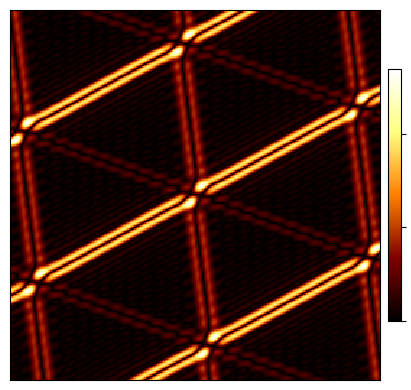

Saved to: C:\Users\Elaina\Desktop\TMDrotor2025\Data analysis\piezo_proxy_afmhot_start0.png


In [9]:
# ==========================
# Plot raw values (no normalization) and hide x/y ticks/labels
# ==========================

from matplotlib.ticker import NullFormatter

def plot_map_real_units(
    data,
    extent=None,
    cmap="afmhot",
    cbar_label="Value (units)",   # <-- put your real units
    out_path=None,
    start_at_zero=True,
    value_range=None,             # (vmin, vmax); if None, use data min/max
    clip_percentiles=None         # e.g., (1, 99) to clip outliers
):
    data = np.abs(data) 
    
    masked = np.ma.masked_invalid(data)

    # choose vmin/vmax
    if value_range is not None:
        vmin, vmax = value_range
    elif clip_percentiles is not None:
        lo, hi = np.percentile(masked.compressed(), clip_percentiles)
        vmin, vmax = float(lo), float(hi)
    else:
        vmin, vmax = float(masked.min()), float(masked.max())

    # extent handling (optionally re-zero to start at 0; preserves orientation)
    if extent is not None:
        x_left, x_right, y_bottom, y_top = map(float, extent)
        if start_at_zero:
            x_len = abs(x_right - x_left)
            y_len = abs(y_top - y_bottom)
            xl, xr = (0.0, x_len) if x_right >= x_left else (x_len, 0.0)
            yb, yt = (0.0, y_len) if y_top >= y_bottom else (y_len, 0.0)
            extent_plot = [xl, xr, yb, yt]
        else:
            extent_plot = [x_left, x_right, y_bottom, y_top]
    else:
        ny, nx = masked.shape
        extent_plot = [0, nx, 0, ny] if start_at_zero else None

    fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.0))
    im = ax.imshow(
        masked,
        origin="lower",
        cmap=cmap,
        interpolation="nearest",
        vmin=vmin, vmax=vmax,
        extent=extent_plot
    )

    # hide x/y ticks and labels (keep frame)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False)

    # colorbar shows REAL units
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label(cbar_label, fontsize=10)
    cbar.ax.tick_params(labelsize=12)

    # --- keep only two ticks (min & max) ---
    cbar.set_ticks([0, 15, 30])                 # your chosen tick locations
    cbar.ax.yaxis.set_major_formatter(NullFormatter())  # hide numbers, keep ticks
    cbar.ax.yaxis.set_minor_formatter(NullFormatter())  # (optional) hide minor labels too
  

    plt.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

# ==========================
# Run (real values, no x/y axis labels)
# ==========================
if __name__ == "__main__":
    data, extent = load_piezo_and_axes(H5_PATH, piezo_name="Psuedomagnetic_fields")
    plot_map_real_units(
        data,
        extent=extent,
        cmap="afmhot",
        cbar_label="",  # <-- set the true units
        out_path=OUT_PNG,
        start_at_zero=True,
        # value_range=(-0.1, 0.1),       # <- uncomment to use exact range
        # clip_percentiles=(1, 99),      # <- or clip outliers
    )
    print(f"Saved to: {OUT_PNG.resolve()}")